### Tools
###### Models can request to call tools that perform tasks such as fetching data from a database, searching from the web, or running code. Tools are pairing of:
######  1. A schema, including the name of the tool, a description, and/or argument definitions (such as JSON schema)   
######   2. A function or corotuine to execute 

In [1]:
import os
from langchain.chat_models import init_chat_model
os.environ["GROQ_API_KEY"] = os.environ.get("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3-32b")
response = model.invoke("Why do parrots talk?")
response.content

'<think>\nOkay, so I need to figure out why parrots talk. I know they can mimic human speech, but why do they actually do that? Let me start by recalling what I know about parrots. They\'re social birds, right? Maybe they talk to communicate with other parrots or with humans. I\'ve heard that some birds use mimicry to attract mates or scare predators. But in captivity, maybe they talk to bond with their owners. \n\nWait, parrots are part of the Psittaciformes order. I think their vocal abilities are related to their syrinx, which is their vocal organ. Maybe their syrinx allows them to produce a wide range of sounds, including human speech. But why would they choose to mimic human words? Could it be a form of social bonding or learning? \n\nI remember reading that parrots are highly intelligent. They might imitate sounds as a way to interact with their environment. In the wild, maybe they mimic other birds or sounds in their habitat. But when kept as pets, they might learn to mimic huma

In [5]:
from langchain.tools import tool

@tool
def get_weather(location: str) -> str:
    """Get the current weather for a given location."""
    # Here you would implement the logic to get the weather for the location
    return f"The current weather in {location} is sunny with a temperature of 25°C."

model_with_tools = model.bind_tools([get_weather])

In [11]:
response = model_with_tools.invoke("What is the weather like in New York?")
for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")

Tool: get_weather
Args: {'location': 'New York'}


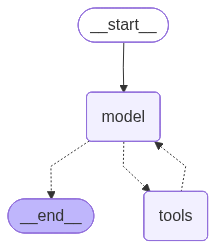

In [20]:
### Another of using tool
from langchain.agents import create_agent
@tool
def get_weather(location: str) -> str:
    """Get the current weather for a given location."""
    # Here you would implement the logic to get the weather for the location
    return f"The current weather in {location} is sunny."

agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[get_weather],
    system_prompt="You are a helpful assistant that can provide weather information.")
agent

In [21]:
response = agent.invoke({"messages": [{"role": "user", "content": "What is the weather in New York City?"}]})
response["messages"][-1].content

"The current weather in New York City is sunny! If you're there, it's a great day to enjoy outdoor activities. Let me know if you need more details! ☀️"

### Tool Execution Loop

In [22]:
#step 1 Model generates tool calls
messages = [{"role": "user", "content": "What is the weather in New York City?"}]
ai_msg = model_with_tools.invoke(messages)
messages.append(ai_msg)

# step2 Execute tool and collect results
for tool_call in ai_msg.tool_calls:
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result) 

# step 3 Pass results back to model for final response
final_response = model_with_tools.invoke(messages)
print(final_response.text)

The current weather in New York City is sunny. Let me know if you'd like additional details! ☀️


In [23]:
messages

[{'role': 'user', 'content': 'What is the weather in New York City?'},
 AIMessage(content='', additional_kwargs={'reasoning_content': 'Okay, the user is asking for the weather in New York City. I need to use the get_weather function they provided. Let me check the function parameters. The function requires a "location" parameter, which is a string. Since the user specified "New York City", I should plug that into the arguments. I\'ll make sure to format the JSON correctly with the function name and the location. No other parameters are needed here. Just call get_weather with location set to New York City.\n', 'tool_calls': [{'id': 'n8ahdsanp', 'function': {'arguments': '{"location":"New York City"}', 'name': 'get_weather'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 125, 'prompt_tokens': 157, 'total_tokens': 282, 'completion_time': 0.213268588, 'completion_tokens_details': {'reasoning_tokens': 99}, 'prompt_time': 0.030412727, 'prompt_tokens_details':